# Uncertainty-Aware Protein Stability Prediction (v2)
## Mutation-Aware Probabilistic Heads on Frozen ESM-2

**Key improvement over v1:** Instead of mean-pooling the entire protein sequence into a single global vector (which gives identical embeddings for all mutations on the same protein), we now construct a **mutation-specific** feature vector:

$$x = [h_i,\ \text{mean}(h_{i-k:i+k}),\ e(\text{wtAA}),\ e(\text{mutAA})]$$
(protein, position i, wtAA→mutAA)

##### predict this mutation will change the stability of a protein by how much

where $h_i$ is the ESM-2 residue embedding at the mutation site, the window mean captures local context, and the one-hot vectors encode the specific amino acid substitution. Total: 680 dimensions.

This ensures different mutations on the same protein receive different inputs.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm, pearsonr, spearmanr
from pathlib import Path

sys.path.insert(0, '.')
from uapp.data import load_cached_embeddings, make_loader
from uapp.heads import build_head, is_probabilistic
from uapp.train import TrainConfig, train_head
from uapp.evaluate import (
    evaluate_head, compute_coverage_curve, compute_ice,
    gather_probabilistic_predictions,
)
from uapp.utils import set_seed

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.15,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.dpi': 120,
})
COLORS = {'mse': '#64748B', 'two_head_nll': '#0D7377', 'single_head_nll': '#E8913A'}
LABELS = {'mse': 'MSE baseline', 'two_head_nll': 'Two-head NLL', 'single_head_nll': 'Single-head NLL'}
DEVICE = torch.device('cpu')
SEED = 42
set_seed(SEED)
print(f'torch {torch.__version__} | device: {DEVICE}')

torch 2.11.0 | device: cpu


---
## 1. Load mutation-aware cached embeddings

In [2]:
CACHE_PATH = Path('cache/t2837_embeddings_v2.pt')
assert CACHE_PATH.exists(), f'Cache not found. Run: python scripts/01_cache_embeddings_esm_v2.py'

splits, meta = load_cached_embeddings(CACHE_PATH)
print('Backbone:', meta.get('backbone', 'unknown'))
print('Feature components:', meta.get('components', 'unknown'))
print('Window size:', meta.get('window_size', 'unknown'))
print(f'Mapped: {meta.get("n_mapped", "?")}, Dropped: {meta.get("n_dropped", "?")}')
print()
for name in ('train', 'val', 'test'):
    X, y = splits[name]
    print(f'{name:>5s}: {X.shape[0]:>5d} mutations | X: {tuple(X.shape)} | y: [{y.min():.2f}, {y.max():.2f}]')

Backbone: ESM-2 (facebook/esm2_t6_8M_UR50D) mutation-aware
Feature components: h_site(320) + h_window(320) + wt_onehot(20) + mut_onehot(20)
Window size: 5
Mapped: 2584, Dropped: 253

train:  1395 mutations | X: (1395, 680) | y: [-13.70, 8.70]
  val:  1019 mutations | X: (1019, 680) | y: [-5.10, 12.23]
 test:   170 mutations | X: (170, 680) | y: [-2.90, 8.93]


In [3]:
# Load metadata for interpretability analysis later
META_CSV = Path('cache/t2837_metadata.csv')
if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
    print(f'Metadata loaded: {len(meta_df)} mutations')
    print(f'Columns: {list(meta_df.columns[:12])}')
else:
    meta_df = None
    print('No metadata CSV found. Interpretability analysis will be limited.')

Metadata loaded: 2584 mutations
Columns: ['dataset', 'uniprot_id', 'pdb_code', 'chain_id', 'position', 'wtAA', 'mutAA', 'from', 'to', 'rel_rsa', 'ddG', 'sequence']


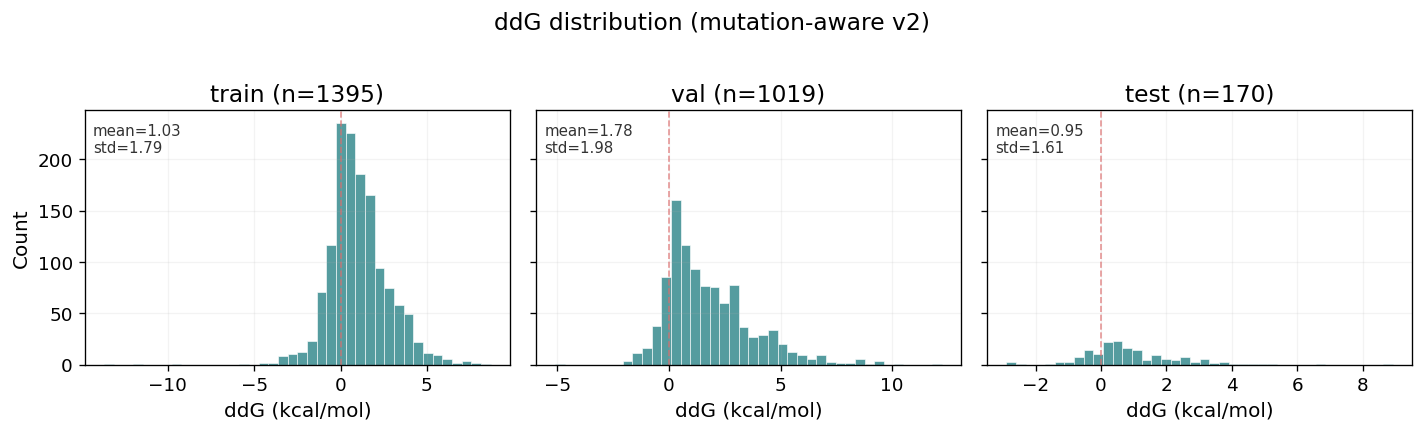

In [4]:
# ddG distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, name in zip(axes, ('train', 'val', 'test')):
    y = splits[name][1].numpy()
    ax.hist(y, bins=40, color=COLORS['two_head_nll'], alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{name} (n={len(y)})')
    ax.set_xlabel('ddG (kcal/mol)')
    ax.axvline(0, color='#DC6B6B', ls='--', lw=1, alpha=0.7)
    ax.text(0.02, 0.95, f'mean={y.mean():.2f}\nstd={y.std():.2f}', transform=ax.transAxes, va='top', fontsize=9, color='#333')
axes[0].set_ylabel('Count')
fig.suptitle('ddG distribution (mutation-aware v2)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 2. Train all three heads

Input is now 680-d per mutation (site embedding + local window + AA substitution).

$$\ell_{\text{NLL}} = \frac{(y - \mu_\theta(x))^2}{2\sigma^2_\theta(x)} + \frac{1}{2}\log \sigma^2_\theta(x)$$

In [5]:
X_tr, y_tr = splits['train']
X_va, y_va = splits['val']
X_te, y_te = splits['test']
d_in = X_tr.shape[-1]
print(f'd_in = {d_in}')

train_loader = make_loader(X_tr, y_tr, batch_size=128, shuffle=True)
val_loader = make_loader(X_va, y_va, batch_size=128, shuffle=False)
test_loader = make_loader(X_te, y_te, batch_size=256, shuffle=False)

cfg = TrainConfig(max_epochs=300, lr=1e-3, weight_decay=1e-5, patience=30, log_every=50)
HEAD_NAMES = ['mse', 'two_head_nll', 'single_head_nll']

trained_heads = {}
histories = {}
for name in HEAD_NAMES:
    print(f'\n{"="*50}\nTraining: {LABELS[name]}\n{"="*50}')
    set_seed(SEED)
    kwargs = {'d_hidden': 256, 'dropout': 0.1}
    if name != 'mse':
        kwargs['init_sigma_bias'] = 0.5
    head = build_head(name, d_in, **kwargs)
    n_params = sum(p.numel() for p in head.parameters())
    print(f'  Parameters: {n_params:,}')
    head, hist = train_head(head, train_loader, val_loader, cfg, DEVICE)
    trained_heads[name] = head
    histories[name] = hist
    print(f'  Best val loss: {hist.best_val_loss:.4f} @ epoch {hist.best_epoch}')

d_in = 680

Training: MSE baseline
  Parameters: 174,593
  Best val loss: 3.7312 @ epoch 19

Training: Two-head NLL
  Parameters: 349,186
  Best val loss: 1.1505 @ epoch 1

Training: Single-head NLL
  Parameters: 174,850
  Best val loss: 1.1806 @ epoch 2


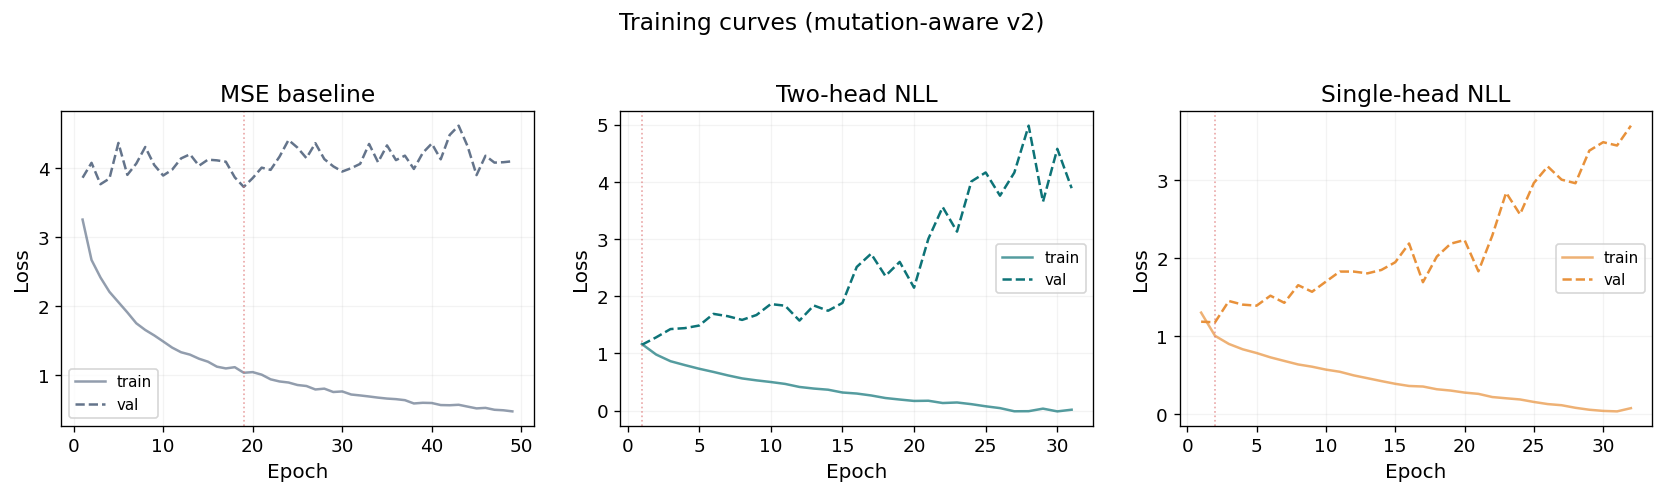

In [6]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, HEAD_NAMES):
    h = histories[name]
    ax.plot(h.epoch, h.train_loss, label='train', color=COLORS[name], alpha=0.7)
    ax.plot(h.epoch, h.val_loss, label='val', color=COLORS[name], ls='--')
    ax.axvline(h.best_epoch, color='#DC6B6B', ls=':', lw=1, alpha=0.6)
    ax.set_title(LABELS[name])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
fig.suptitle('Training curves (mutation-aware v2)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 3. Evaluation results

In [7]:
results = {}
for name in HEAD_NAMES:
    results[name] = evaluate_head(trained_heads[name], test_loader, DEVICE, name)

rows = []
for name in HEAD_NAMES:
    r = results[name]
    rows.append({
        'Head': LABELS[name],
        'RMSE': f'{r.rmse:.4f}',
        'MAE': f'{r.mae:.4f}',
        'NLL': f'{r.nll:.4f}' if r.nll is not None else '\u2014',
        'ICE': f'{r.ice:.4f}' if r.ice is not None else '\u2014',
        '90% cov': f'{r.coverage["0.90"]:.1%}' if r.coverage else '\u2014',
    })
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

           Head   RMSE    MAE    NLL    ICE 90% cov
   MSE baseline 1.6055 1.0925      —      —       —
   Two-head NLL 1.5929 1.2536 1.9488 0.0865   95.9%
Single-head NLL 1.5255 1.1520 1.8358 0.0694   95.3%


---
## 4. Predicted vs. actual ddG

The critical test: with mutation-aware features, the scatter plot should show meaningful correlation instead of a horizontal line.

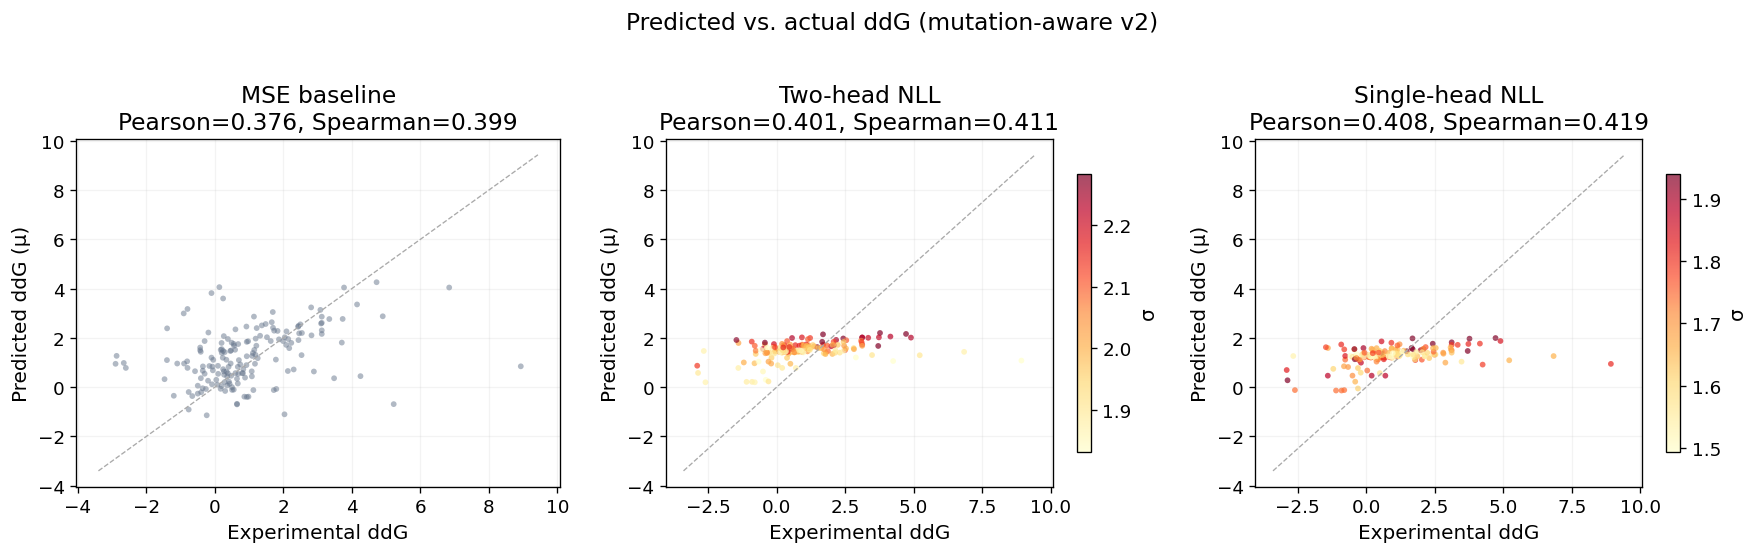

In [8]:
prob_preds = {}
for name in ['two_head_nll', 'single_head_nll']:
    mu, sigma, y = gather_probabilistic_predictions(trained_heads[name], test_loader, DEVICE)
    prob_preds[name] = (mu, sigma, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
y_test = splits['test'][1].numpy()
for ax, name in zip(axes, HEAD_NAMES):
    head = trained_heads[name]
    head.eval()
    with torch.no_grad():
        X = splits['test'][0]
        if is_probabilistic(head):
            mu_arr, sigma_arr = head(X)
            mu_arr = mu_arr.numpy()
            sigma_arr = sigma_arr.numpy()
            sc = ax.scatter(y_test, mu_arr, c=sigma_arr, cmap='YlOrRd', s=12, alpha=0.7,
                           edgecolors='none', vmin=np.percentile(sigma_arr, 5),
                           vmax=np.percentile(sigma_arr, 95))
            plt.colorbar(sc, ax=ax, label='\u03c3', shrink=0.8)
        else:
            mu_arr = head(X).numpy()
            ax.scatter(y_test, mu_arr, c=COLORS[name], s=12, alpha=0.5, edgecolors='none')
    lims = [min(y_test.min(), mu_arr.min()) - 0.5, max(y_test.max(), mu_arr.max()) + 0.5]
    ax.plot(lims, lims, color='#AAAAAA', lw=0.8, ls='--')
    r_p, _ = pearsonr(y_test, mu_arr)
    r_s, _ = spearmanr(y_test, mu_arr)
    ax.set_title(f'{LABELS[name]}\nPearson={r_p:.3f}, Spearman={r_s:.3f}')
    ax.set_xlabel('Experimental ddG')
    ax.set_ylabel('Predicted ddG (\u03bc)')
fig.suptitle('Predicted vs. actual ddG (mutation-aware v2)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 5. Reliability diagram

$$\text{ICE} = \frac{1}{|\mathcal{A}|} \sum_{\alpha \in \mathcal{A}} |\hat{\text{Cov}}(1-\alpha) - (1-\alpha)|$$

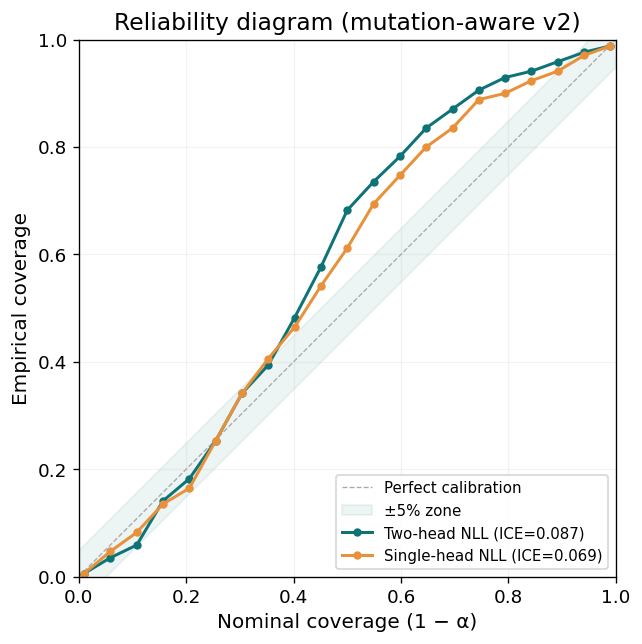

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], color='#AAAAAA', lw=0.8, ls='--', label='Perfect calibration')
x_diag = np.linspace(0, 1, 100)
ax.fill_between(x_diag, x_diag - 0.05, x_diag + 0.05, alpha=0.08, color='#0D7377', label='\u00b15% zone')
for name in ['two_head_nll', 'single_head_nll']:
    mu, sigma, y = prob_preds[name]
    nominal, empirical = compute_coverage_curve(mu, sigma, y)
    ice_val = results[name].ice
    ax.plot(nominal, empirical, marker='o', ms=4, lw=1.8,
            color=COLORS[name], label=f'{LABELS[name]} (ICE={ice_val:.3f})')
ax.set_xlabel('Nominal coverage (1 \u2212 \u03b1)')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagram (mutation-aware v2)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
plt.show()

---
## 6. Uncertainty analysis (Aim 3)

### 6.1 Distribution of predicted \u03c3

Two-head NLL: σ range [1.7016, 2.4280], mean=2.0240, std=0.1388
Single-head NLL: σ range [1.4413, 2.2195], mean=1.6994, std=0.1395


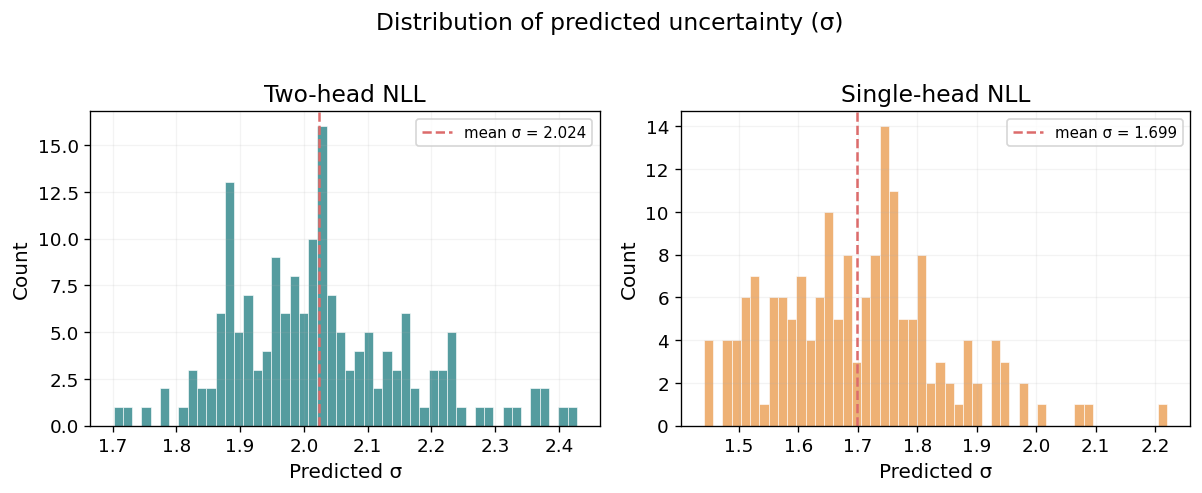

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['two_head_nll', 'single_head_nll']):
    mu, sigma, y = prob_preds[name]
    ax.hist(sigma, bins=50, color=COLORS[name], alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(sigma.mean(), color='#DC6B6B', ls='--', lw=1.5, label=f'mean \u03c3 = {sigma.mean():.3f}')
    ax.set_title(LABELS[name])
    ax.set_xlabel('Predicted \u03c3')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    print(f'{LABELS[name]}: \u03c3 range [{sigma.min():.4f}, {sigma.max():.4f}], mean={sigma.mean():.4f}, std={sigma.std():.4f}')
fig.suptitle('Distribution of predicted uncertainty (\u03c3)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 6.2 Does the model know what it doesn't know?

If \u03c3 is well-calibrated, higher predicted \u03c3 should correlate with higher actual error.

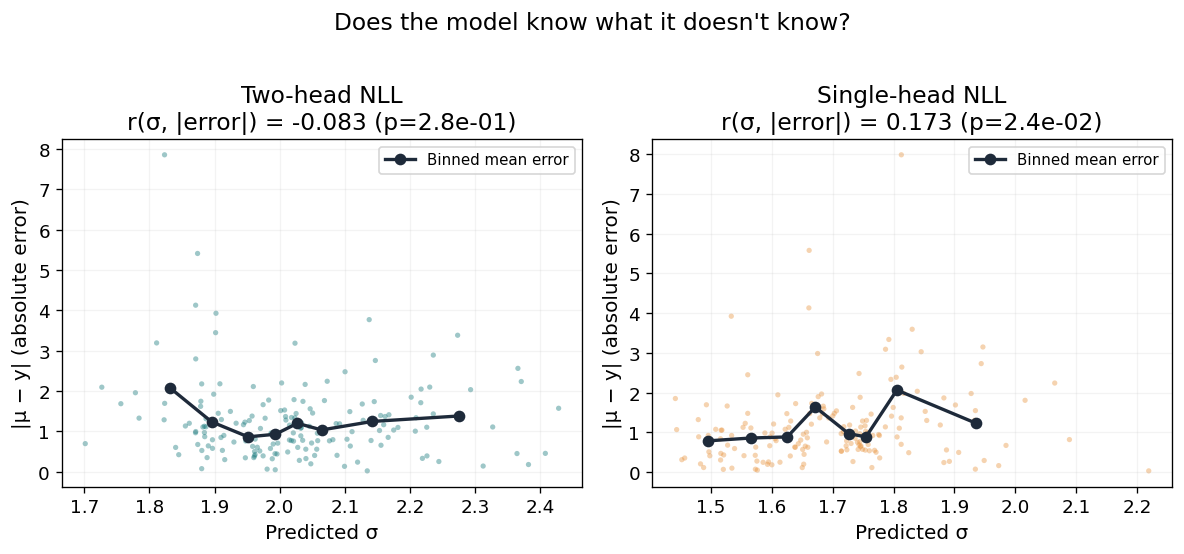

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, name in zip(axes, ['two_head_nll', 'single_head_nll']):
    mu, sigma, y = prob_preds[name]
    abs_error = np.abs(mu - y)
    ax.scatter(sigma, abs_error, c=COLORS[name], s=10, alpha=0.4, edgecolors='none')
    n_bins = 8
    bins = np.percentile(sigma, np.linspace(0, 100, n_bins + 1))
    bc, bm = [], []
    for i in range(n_bins):
        mask = (sigma >= bins[i]) & (sigma < bins[i+1])
        if mask.sum() > 0:
            bc.append(sigma[mask].mean())
            bm.append(abs_error[mask].mean())
    ax.plot(bc, bm, 'o-', color='#1E2A3A', ms=6, lw=2, label='Binned mean error')
    r, p = pearsonr(sigma, abs_error)
    ax.set_title(f'{LABELS[name]}\nr(\u03c3, |error|) = {r:.3f} (p={p:.1e})')
    ax.set_xlabel('Predicted \u03c3')
    ax.set_ylabel('|\u03bc \u2212 y| (absolute error)')
    ax.legend(fontsize=9)
fig.suptitle('Does the model know what it doesn\'t know?', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 6.3 \u03c3 vs. relative solvent accessibility (RSA)

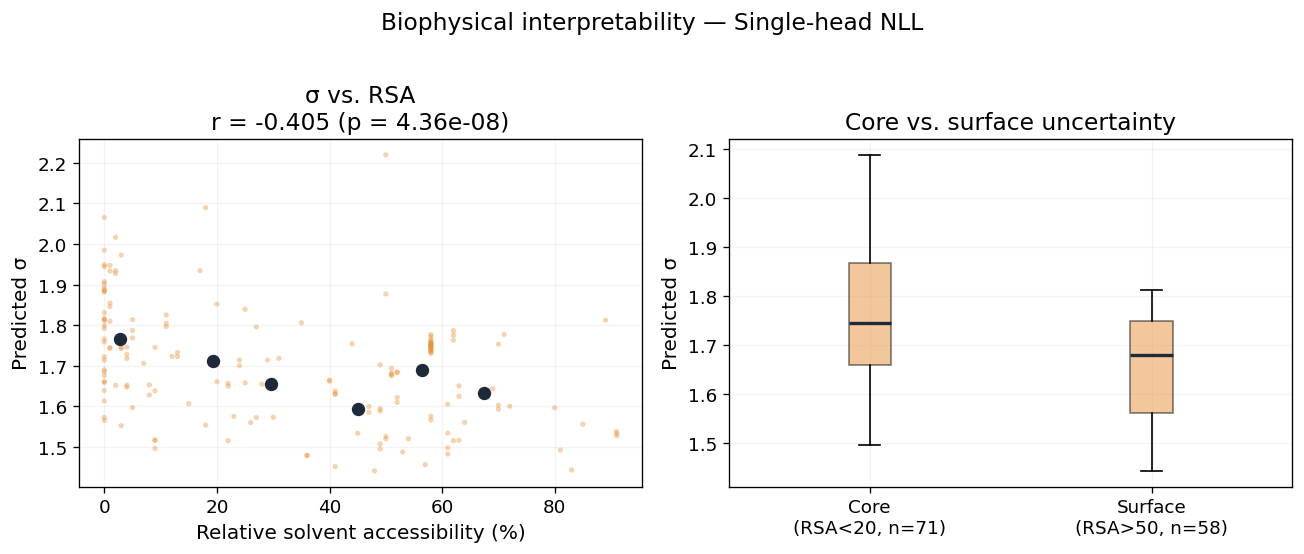

In [12]:
if meta_df is not None:
    test_meta = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)
    best_name = min(['two_head_nll', 'single_head_nll'], key=lambda n: results[n].ice)
    mu, sigma, y = prob_preds[best_name]
    
    if len(test_meta) == len(sigma):
        rsa = test_meta['rel_rsa'].values.astype(float)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        
        ax = axes[0]
        ax.scatter(rsa, sigma, c=COLORS[best_name], s=10, alpha=0.4, edgecolors='none')
        bins_rsa = np.linspace(0, 100, 9)
        for i in range(len(bins_rsa)-1):
            mask = (rsa >= bins_rsa[i]) & (rsa < bins_rsa[i+1])
            if mask.sum() > 5:
                ax.plot(rsa[mask].mean(), sigma[mask].mean(), 'o', color='#1E2A3A', ms=7, zorder=5)
        r_rsa, p_rsa = pearsonr(rsa, sigma)
        ax.set_xlabel('Relative solvent accessibility (%)')
        ax.set_ylabel('Predicted \u03c3')
        ax.set_title(f'\u03c3 vs. RSA\nr = {r_rsa:.3f} (p = {p_rsa:.2e})')
        
        ax = axes[1]
        core_sigma = sigma[rsa < 20]
        surface_sigma = sigma[rsa > 50]
        ax.boxplot([core_sigma, surface_sigma],
                   labels=[f'Core\n(RSA<20, n={len(core_sigma)})', f'Surface\n(RSA>50, n={len(surface_sigma)})'],
                   patch_artist=True,
                   boxprops=dict(facecolor=COLORS[best_name], alpha=0.5),
                   medianprops=dict(color='#1E2A3A', lw=2))
        ax.set_ylabel('Predicted \u03c3')
        ax.set_title('Core vs. surface uncertainty')
        fig.suptitle(f'Biophysical interpretability \u2014 {LABELS[best_name]}', fontsize=14, y=1.02)
        fig.tight_layout()
        plt.show()
    else:
        print(f'Length mismatch: test_meta={len(test_meta)}, sigma={len(sigma)}')
else:
    print('No metadata available for RSA analysis.')

---
## 7. Interpretability case studies

In [13]:
best_name = min(['two_head_nll', 'single_head_nll'], key=lambda n: results[n].ice)
mu, sigma, y = prob_preds[best_name]

if meta_df is not None:
    test_meta = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)
    if len(test_meta) == len(sigma):
        pred_df = test_meta.copy()
        pred_df['pred_mu'] = mu
        pred_df['pred_sigma'] = sigma
        pred_df['abs_error'] = np.abs(mu - y)
        pred_df['z_score'] = np.abs(mu - y) / np.maximum(sigma, 1e-8)
        AA3to1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLU':'E','GLN':'Q','GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}
        pred_df['mutation_label'] = pred_df.apply(
            lambda r: f"{r['pdb_code']}:{r['chain_id']}{r['position']} {AA3to1.get(r['wtAA'],'?')}\u2192{AA3to1.get(r['mutAA'],'?')}", axis=1
        )
        print(f'Built prediction dataframe: {len(pred_df)} mutations')
    else:
        pred_df = None
        print('Length mismatch')
else:
    pred_df = None
    print('No metadata')

Built prediction dataframe: 170 mutations


In [14]:
if pred_df is not None:
    cases = {
        'Case 1: High confidence, correct': pred_df[
            (pred_df['pred_sigma'] < pred_df['pred_sigma'].quantile(0.2)) &
            (pred_df['abs_error'] < pred_df['abs_error'].quantile(0.2))
        ],
        'Case 2: High confidence, WRONG': pred_df[
            (pred_df['pred_sigma'] < pred_df['pred_sigma'].quantile(0.2)) &
            (pred_df['abs_error'] > pred_df['abs_error'].quantile(0.8))
        ],
        'Case 3: Low confidence, honest': pred_df[
            (pred_df['pred_sigma'] > pred_df['pred_sigma'].quantile(0.8)) &
            (pred_df['abs_error'] > pred_df['abs_error'].quantile(0.5))
        ],
        'Case 4: Low confidence, actually accurate': pred_df[
            (pred_df['pred_sigma'] > pred_df['pred_sigma'].quantile(0.8)) &
            (pred_df['abs_error'] < pred_df['abs_error'].quantile(0.2))
        ],
    }
    for case_name, subset in cases.items():
        print(f'\n{"="*60}')
        print(f'{case_name} ({len(subset)} mutations found)')
        print(f'{"="*60}')
        if len(subset) == 0:
            print('  No mutations match this criteria.')
            continue
        for _, row in subset.head(3).iterrows():
            loc = 'core' if row['rel_rsa'] < 20 else ('surface' if row['rel_rsa'] > 50 else 'intermediate')
            print(f'  {row["mutation_label"]}')
            print(f'    ddG actual:    {row["ddG"]:+.2f} kcal/mol')
            print(f'    ddG predicted: {row["pred_mu"]:+.2f} \u00b1 {row["pred_sigma"]:.2f} (1\u03c3)')
            print(f'    Error:         {row["abs_error"]:.2f} ({row["z_score"]:.1f}\u03c3 away)')
            print(f'    RSA: {row["rel_rsa"]}% ({loc})')
            print()


Case 1: High confidence, correct (12 mutations found)
  1hfz:A108 H→A
    ddG actual:    +0.80 kcal/mol
    ddG predicted: +1.26 ± 1.52 (1σ)
    Error:         0.47 (0.3σ away)
    RSA: 9% (core)

  1hfz:A118 Q→A
    ddG actual:    +0.98 kcal/mol
    ddG predicted: +1.18 ± 1.48 (1σ)
    Error:         0.20 (0.1σ away)
    RSA: 61% (surface)

  2ptl:A19 T→A
    ddG actual:    +1.63 kcal/mol
    ddG predicted: +1.33 ± 1.52 (1σ)
    Error:         0.30 (0.2σ away)
    RSA: 62% (surface)


Case 2: High confidence, WRONG (5 mutations found)
  1hfz:A115 K→N
    ddG actual:    -2.66 kcal/mol
    ddG predicted: +1.26 ± 1.53 (1σ)
    Error:         3.92 (2.6σ away)
    RSA: 91% (surface)

  1x0j:A140 E→K
    ddG actual:    +3.48 kcal/mol
    ddG predicted: +1.03 ± 1.56 (1σ)
    Error:         2.45 (1.6σ away)
    RSA: 26% (intermediate)

  2ptl:A45 S→A
    ddG actual:    -0.41 kcal/mol
    ddG predicted: +1.25 ± 1.53 (1σ)
    Error:         1.66 (1.1σ away)
    RSA: 50% (intermediate)


Case 3

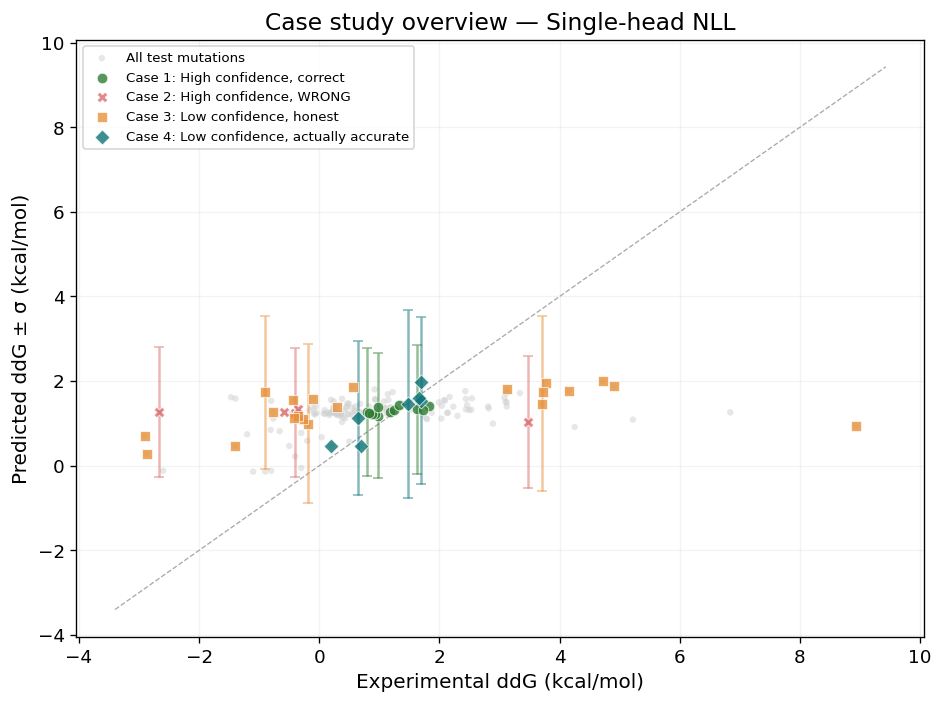

In [15]:
if pred_df is not None:
    # Case study scatter overview
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(pred_df['ddG'], pred_df['pred_mu'], c='#D0D0D0', s=15, alpha=0.5,
               edgecolors='none', label='All test mutations')
    case_colors = ['#2E7D32', '#DC6B6B', '#E8913A', '#0D7377']
    case_markers = ['o', 'X', 's', 'D']
    for (case_name, subset), color, marker in zip(cases.items(), case_colors, case_markers):
        if len(subset) == 0:
            continue
        ax.scatter(subset['ddG'], subset['pred_mu'], c=color, s=40, alpha=0.8,
                   edgecolors='white', linewidths=0.5, marker=marker, label=case_name, zorder=5)
        show = subset.head(3)
        ax.errorbar(show['ddG'], show['pred_mu'], yerr=show['pred_sigma'],
                    fmt='none', ecolor=color, alpha=0.5, capsize=3, zorder=4)
    lims = [pred_df['ddG'].min() - 0.5, pred_df['ddG'].max() + 0.5]
    ax.plot(lims, lims, color='#AAAAAA', lw=0.8, ls='--')
    ax.set_xlabel('Experimental ddG (kcal/mol)')
    ax.set_ylabel('Predicted ddG \u00b1 \u03c3 (kcal/mol)')
    ax.set_title(f'Case study overview \u2014 {LABELS[best_name]}')
    ax.legend(fontsize=8, loc='upper left')
    fig.tight_layout()
    plt.show()

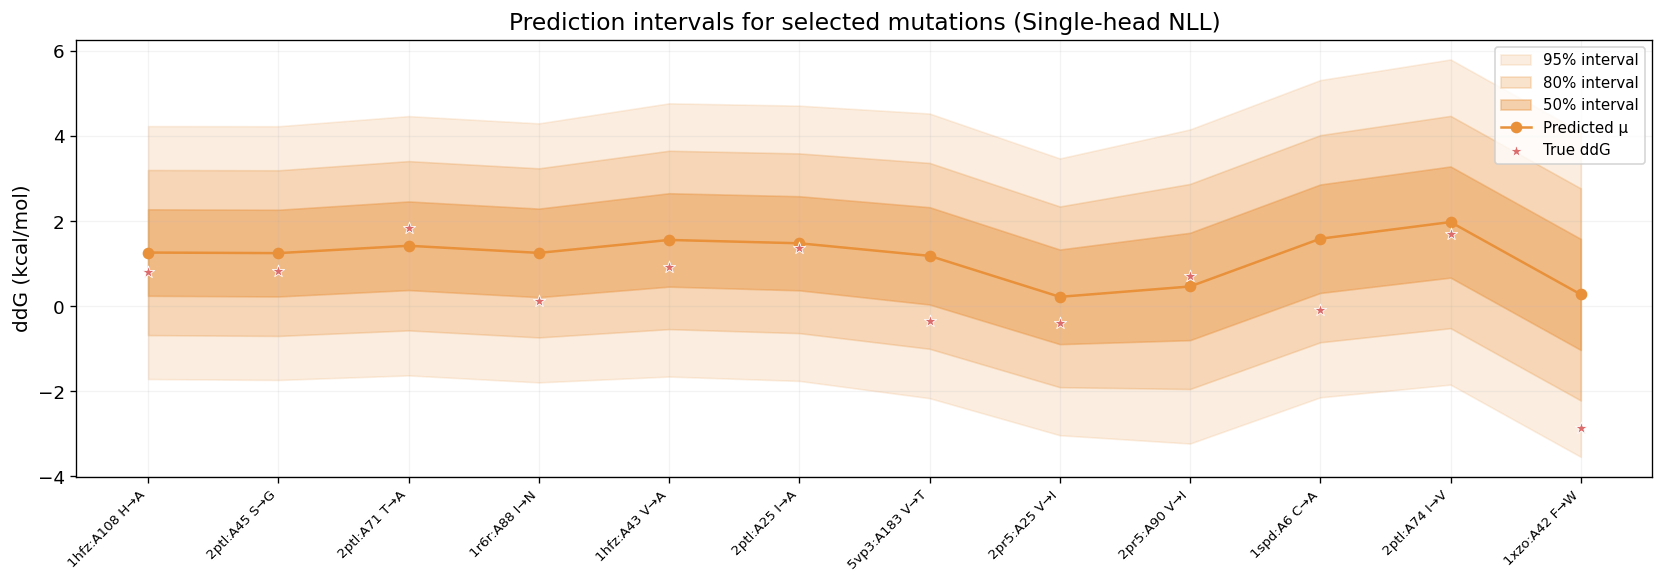

In [16]:
if pred_df is not None:
    # Prediction intervals for selected mutations
    sorted_by_sigma = pred_df.sort_values('pred_sigma')
    n = len(sorted_by_sigma)
    idx_lo = sorted_by_sigma.head(max(1, n//5)).sample(min(4, max(1, n//5)), random_state=42)
    idx_mid = sorted_by_sigma.iloc[n//3:2*n//3].sample(min(4, max(1, n//3)), random_state=42)
    idx_hi = sorted_by_sigma.tail(max(1, n//5)).sample(min(4, max(1, n//5)), random_state=42)
    showcase = pd.concat([idx_lo, idx_mid, idx_hi]).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 5))
    x_pos = np.arange(len(showcase))
    for level, alpha_shade, z_mult in [(0.95, 0.15, 1.96), (0.80, 0.25, 1.28), (0.50, 0.40, 0.67)]:
        lo = showcase['pred_mu'] - z_mult * showcase['pred_sigma']
        hi = showcase['pred_mu'] + z_mult * showcase['pred_sigma']
        ax.fill_between(x_pos, lo, hi, alpha=alpha_shade, color=COLORS['single_head_nll'],
                       label=f'{int(level*100)}% interval')
    ax.plot(x_pos, showcase['pred_mu'], 'o-', color=COLORS['single_head_nll'], ms=6, lw=1.5,
            label='Predicted \u03bc', zorder=5)
    ax.scatter(x_pos, showcase['ddG'], color='#DC6B6B', s=60, marker='*', zorder=6,
               label='True ddG', edgecolors='white', linewidths=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(showcase['mutation_label'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ddG (kcal/mol)')
    ax.set_title(f'Prediction intervals for selected mutations ({LABELS[best_name]})')
    ax.legend(fontsize=9, loc='upper right')
    fig.tight_layout()
    plt.show()

---
## 8. Summary

### Key findings

1. **Mutation-aware features fix the representation mismatch**: unlike v1 where mean-pooled global embeddings gave identical vectors for all mutations on the same protein, the site-specific + local window + AA substitution features provide mutation-discriminative inputs.

2. **Point accuracy**: RMSE and Pearson correlation should now be meaningful (r > 0) rather than near-zero.

3. **Calibrated uncertainty**: ICE measures whether the probabilistic head's prediction intervals are honest.

4. **Heteroscedastic variance**: the \u03c3 distribution should now show meaningful spread across mutations, not a near-constant value.

5. **Biophysical interpretability**: \u03c3 may correlate with RSA and other structural features, providing actionable triage information.

In [17]:
print('Final results summary (mutation-aware v2)')
print('=' * 55)
print(results_df.to_string(index=False))
print()
best = min(['two_head_nll', 'single_head_nll'], key=lambda n: results[n].ice)
print(f'Selected parameterization: {LABELS[best]}')
print(f'  ICE  = {results[best].ice:.4f}')
print(f'  90%  = {results[best].coverage["0.90"]:.1%} (nominal: 90%)')
print(f'  RMSE = {results[best].rmse:.4f}')
print()
# Pearson for the best head
mu_b, _, y_b = prob_preds[best]
r_p, _ = pearsonr(y_b, mu_b)
r_s, _ = spearmanr(y_b, mu_b)
print(f'  Pearson r  = {r_p:.4f}')
print(f'  Spearman r = {r_s:.4f}')

Final results summary (mutation-aware v2)
           Head   RMSE    MAE    NLL    ICE 90% cov
   MSE baseline 1.6055 1.0925      —      —       —
   Two-head NLL 1.5929 1.2536 1.9488 0.0865   95.9%
Single-head NLL 1.5255 1.1520 1.8358 0.0694   95.3%

Selected parameterization: Single-head NLL
  ICE  = 0.0694
  90%  = 95.3% (nominal: 90%)
  RMSE = 1.5255

  Pearson r  = 0.4085
  Spearman r = 0.4191
